In [1]:
import warnings
warnings.filterwarnings('ignore')
!pip install numpy
!pip install -U "cupy-cuda13x[ctk]"
!pip install types-array-api
!pip install array-api-compat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 MB 1.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 MB 14.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 MB 6.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 MB 12.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.7/244.7 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 MB 7.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 11.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 MB 18.2 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: cuda-toolkit
    Found existing installation: cuda-toolkit 12.8.1
    Uninstalling cuda-toolkit-12.8.1:
      Successfully uninstalled cuda-toolkit-12.8.1
ERROR: pip's dependen

In [2]:
!git clone https://github.com/Ankit-539/QuanSToS.git

Cloning into 'QuanSToS'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 159 (delta 98), reused 83 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (159/159), 950.61 KiB | 21.60 MiB/s, done.
Resolving deltas: 100% (98/98), done.


In [ ]:
%cd QuanSToS

/content/QuanSToS


In [1]:
import math
from time import perf_counter

# import cupy as cp
import numpy as np
from array_api.latest import Array, ArrayNamespace
import array_api_compat
import array_api_compat.cupy as cp
import matplotlib.pyplot as plt

from src import (
    get_random_haar,
    get_random_mixed,
    get_random_product,
    get_random_product_pole_biased,
    inverse_estimator,
    negativity,
    pauli_measurement,
    plot_counts,
    bloch_vector,
    benchmark_function
)

# Virtual Pauli measurements

XXX  [12614 12391 12493 12677 12332 12544 12581 12368]
XXY  [12456 12410 12659 12386 12393 12644 12655 12397]
XXZ  [21153  3663 21276  3674 21447  3775 21288  3724]
XYX  [12640 12722 12423 12250 12537 12484 12497 12447]
XYY  [12399 12564 12671 12542 12410 12542 12480 12392]
XYZ  [21434  3780 21247  3684 21184  3684 21164  3823]
XZX  [21217 21248  3804  3784 20923 21538  3694  3792]
XZY  [21026 21341  3728  3758 21447 21267  3729  3704]
XZZ  [38705  3753  3682  3749 38814  3724  3846  3727]
YXX  [12500 12435 12604 12630 12517 12344 12374 12596]
YXY  [12355 12535 12507 12467 12671 12460 12603 12402]
YXZ  [20966  3738 21384  3815 21269  3745 21307  3776]
YYX  [12370 12535 12699 12382 12394 12459 12610 12551]
YYY  [12663 12649 12380 12626 12369 12416 12484 12413]
YYZ  [21310  3722 21377  3839 20996  3834 21162  3760]
YZX  [21141 21376  3844  3804 21182 21289  3679  3685]
YZY  [21308 21131  3769  3716 21131 21462  3739  3744]
YZZ  [38714  3576  3805  3756 38944  3704  3811  3690]
ZXX  [2149

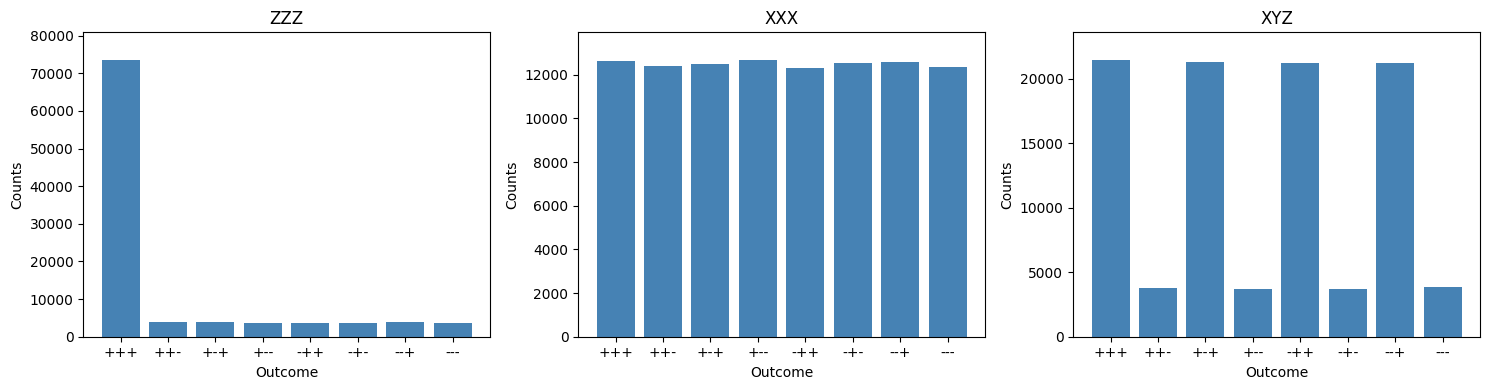

In [5]:
p = 0.7
rho_000 = np.zeros((8, 8), dtype=np.complex128)
rho_000[0, 0] = 1
rho_partial = (p*rho_000 + (1-p)*np.eye(8, dtype=np.complex128)/8)

N = 100_000

result = pauli_measurement(rho_partial, N)

print(result)

plot_counts(result,["ZZZ", "XXX", "XYZ"])

XXX  [12442 12560 12409 12522 12393 12641 12495 12538]
XXY  [12377 12309 12530 12785 12563 12554 12378 12504]
XXZ  [24982     0 25000     0 25123     0 24895     0]
XYX  [12460 12583 12353 12399 12578 12683 12478 12466]
XYY  [12553 12459 12357 12586 12477 12546 12519 12503]
XYZ  [25055     0 25221     0 24878     0 24846     0]
XZX  [24920 25088     0     0 24943 25049     0     0]
XZY  [24901 25046     0     0 25063 24990     0     0]
XZZ  [50148     0     0     0 49852     0     0     0]
YXX  [12471 12613 12481 12346 12614 12459 12694 12322]
YXY  [12371 12460 12570 12516 12596 12373 12532 12582]
YXZ  [24945     0 24959     0 25060     0 25036     0]
YYX  [12530 12495 12383 12241 12545 12636 12573 12597]
YYY  [12396 12445 12508 12580 12423 12616 12610 12422]
YYZ  [24972     0 24984     0 24974     0 25070     0]
YZX  [25026 25033     0     0 24881 25060     0     0]
YZY  [25268 24751     0     0 24947 25034     0     0]
YZZ  [49809     0     0     0 50191     0     0     0]
ZXX  [2489

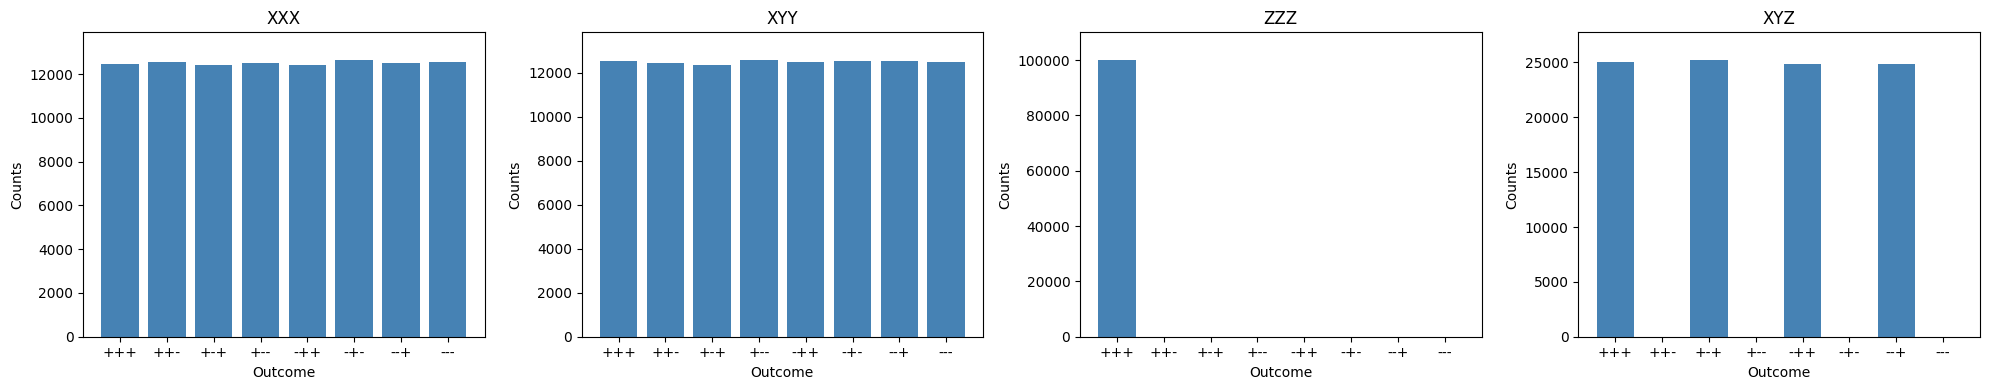

In [6]:
rho_000_cp = cp.zeros((8, 8), dtype=cp.complex128)
rho_000_cp[0, 0] = 1

N = 100_000

result_cp = pauli_measurement(rho_000_cp, N)

print(result_cp)
plot_counts(
    result_cp,
    ["XXX", "XYY", "ZZZ", "XYZ"]
)

100000


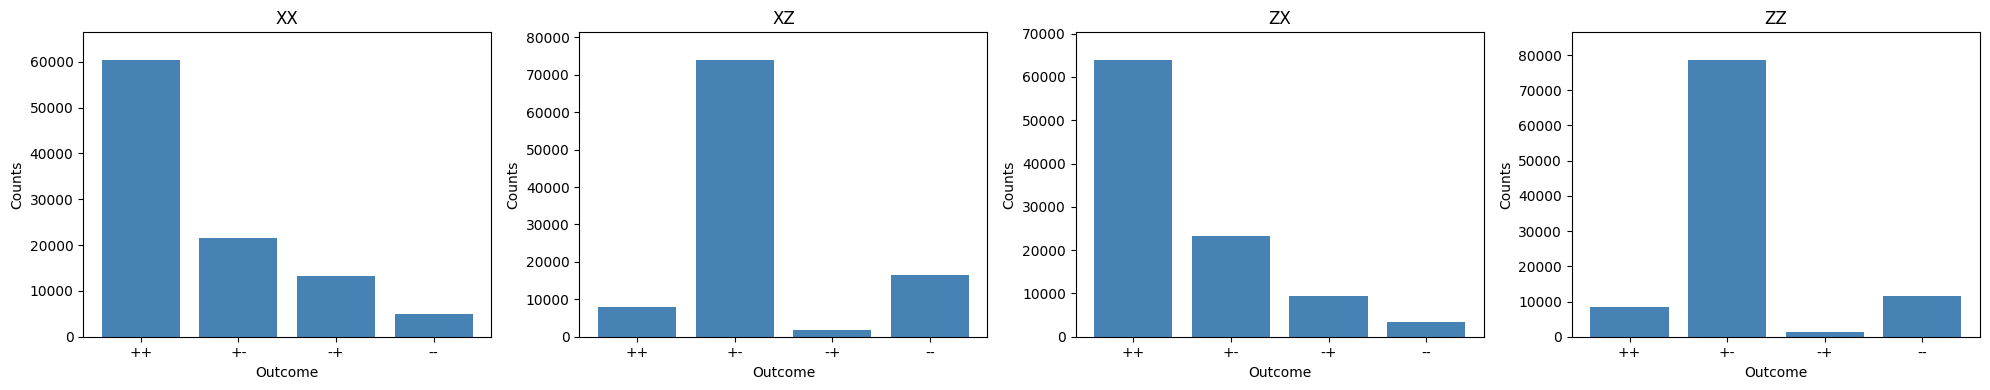

In [7]:
rho = get_random_product(2, array_api_compat.numpy, np.random)

N = 100_000

result = pauli_measurement(rho, N)

print(result.N)

plot_counts(result, ["XX", "XZ", "ZX", "ZZ"])

100000


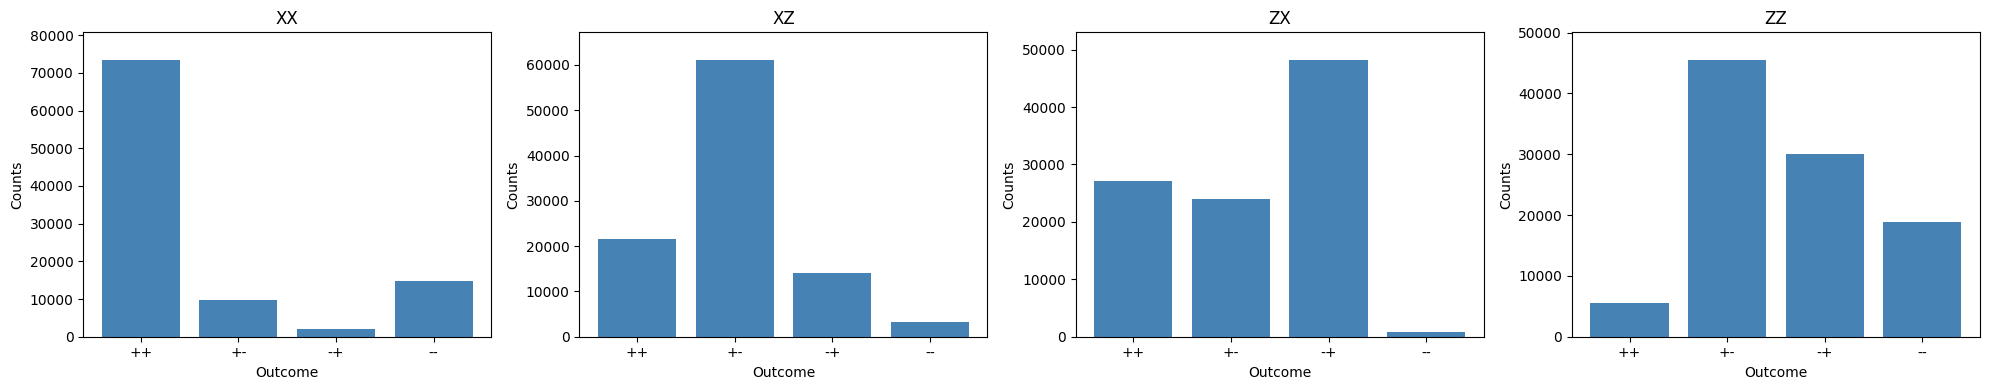

In [8]:
rho = get_random_haar(2, array_api_compat.numpy, np.random)

N = 100_000

result = pauli_measurement(rho, N)

print(result.N)

plot_counts(result, ["XX", "XZ", "ZX", "ZZ"])

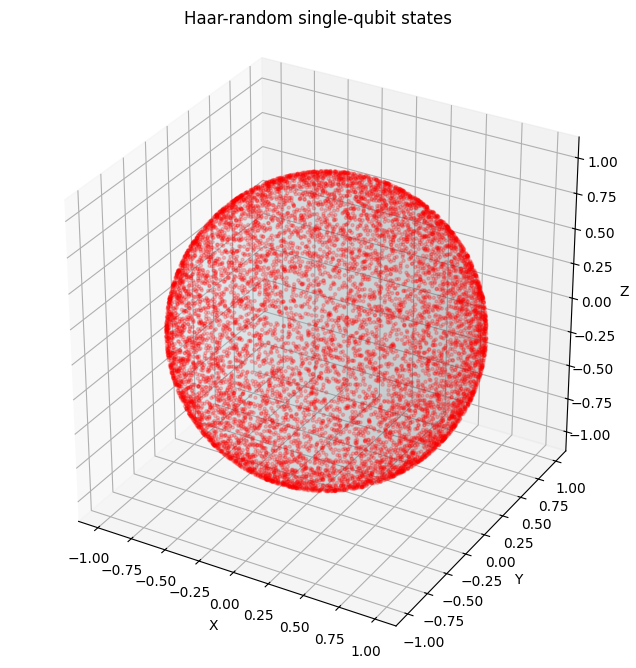

In [9]:
bloch_vectors = []
num_samples = 10000

for _ in range(num_samples):
    rho = get_random_haar(1, array_api_compat.numpy, np.random)
    r = bloch_vector(rho)
    bloch_vectors.append(r)

rng = np.random.default_rng(42)

vectors_np = np.asarray(bloch_vectors)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Bloch sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)

x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    x_sphere,
    y_sphere,
    z_sphere,
    color="lightblue",
    alpha=0.15,
    linewidth=0
)

# Haar-random states
ax.scatter(
    vectors_np[:, 0],
    vectors_np[:, 1],
    vectors_np[:, 2],
    s=5,
    alpha=0.2,
    color="red"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Haar-random single-qubit states")

ax.set_box_aspect([1, 1, 1])

plt.show()

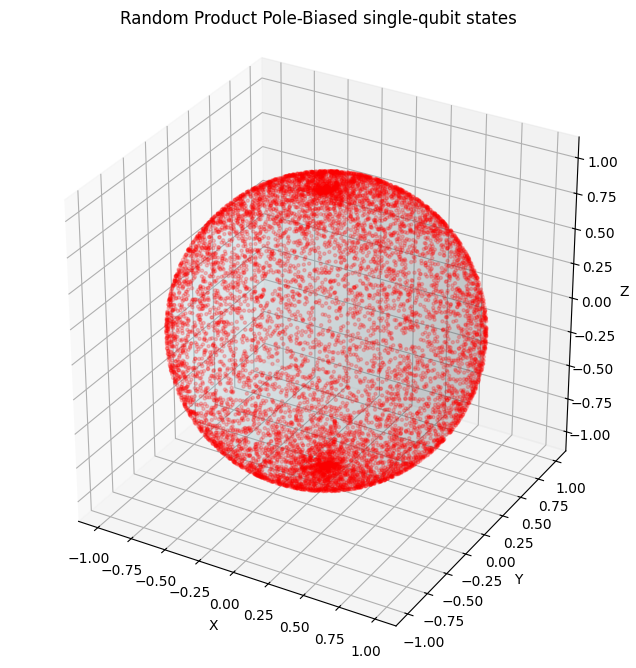

In [10]:
bloch_vectors = []
num_samples = 10000

for _ in range(num_samples):
    rho = get_random_product_pole_biased(1, array_api_compat.numpy, np.random)
    r = bloch_vector(rho)
    bloch_vectors.append(r)

rng = np.random.default_rng(42)

vectors_np = np.asarray(bloch_vectors)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Bloch sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)

x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    x_sphere,
    y_sphere,
    z_sphere,
    color="lightblue",
    alpha=0.15,
    linewidth=0
)

# Haar-random states
ax.scatter(
    vectors_np[:, 0],
    vectors_np[:, 1],
    vectors_np[:, 2],
    s=5,
    alpha=0.2,
    color="red"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Random Product Pole-Biased single-qubit states")

ax.set_box_aspect([1, 1, 1])

plt.show()

In [ ]:
xp = np

zero = xp.asarray([1, 0], dtype=xp.complex128)
plus = xp.asarray([1, 1], dtype=xp.complex128) / xp.sqrt(2)

psi = xp.kron(zero, plus)
rho = xp.outer(psi, xp.conj(psi))

result = pauli_measurement(rho, 100_000)

for measurement in ["ZX", "XZ"]:
    i = result.measurements.index(measurement)
    print(measurement, result.counts[i])

ZX [100000      0      0      0]
XZ [25311 24931 25109 24649]


XY [24946 24976 25308 24770]
YX [49839     0 50161     0]


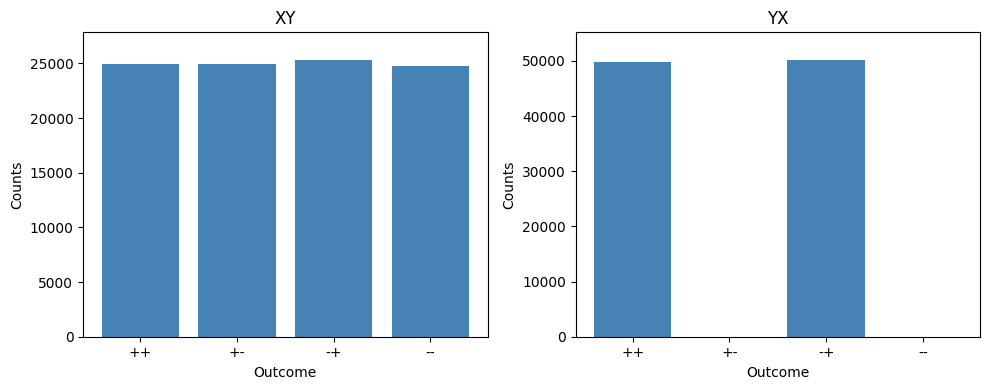

In [12]:
zero = xp.asarray([1, 0], dtype=xp.complex128)
one  = xp.asarray([0, 1], dtype=xp.complex128)

plus_x = (zero + one) / xp.sqrt(2)
plus_y = (zero + 1j * one) / xp.sqrt(2)

psi = xp.kron(plus_x, plus_y)
rho = xp.outer(psi, xp.conj(psi))

for measurement in ["XY", "YX"]:
    i = result.measurements.index(measurement)
    print(measurement, result.counts[i])

plot_counts(result, ["XY", "YX"])

# Hardware Benchmarking

In [ ]:
benchmarks = {
    "Product": (
        get_random_product,
        range(2, 15)
    ),

    "Product (pole biased)": (
        get_random_product_pole_biased,
        range(2, 15)
    ),

    "Haar": (
        get_random_haar,
        range(2, 14)
    ),

    "Mixed": (
        get_random_mixed,
        range(2, 12)
    ),
}

### CPU (NumPy)

In [ ]:
results_np = {}

for name, func in functions.items():

    print(f"Benchmarking NumPy: {name}")
    results_np[name] = benchmark_function(func, n_values, np, rng_np, repeats=10)

Benchmarking NumPy: Product
Benchmarking NumPy: Product (pole biased)
Benchmarking NumPy: Haar
Benchmarking NumPy: Mixed


### GPU (CuPy)

In [ ]:
results_cp = {}

for name, func in functions.items():

    print(f"Benchmarking CuPy: {name}")

    results_cp[name] = benchmark_function(func, n_values, cp, rng_cp, repeats=10)

Benchmarking CuPy: Product
Benchmarking CuPy: Product (pole biased)
Benchmarking CuPy: Haar
Benchmarking CuPy: Mixed


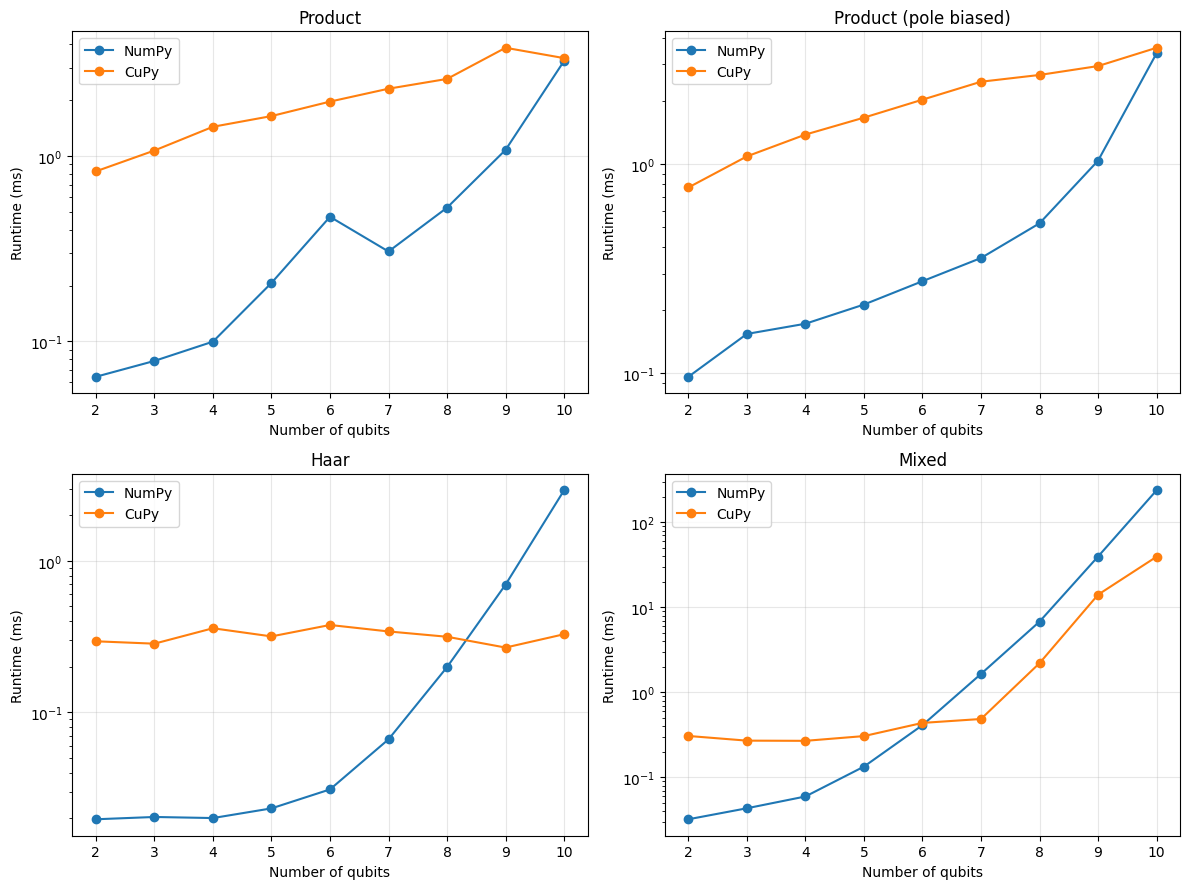

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

axes = axes.flatten()

for ax, name in zip(axes, functions):

    # NumPy
    ax.plot(
        list(n_values),
        results_np[name],
        marker="o",
        label="NumPy"
    )

    # CuPy
    ax.plot(
        list(n_values),
        results_cp[name],
        marker="o",
        label="CuPy"
    )

    ax.set_title(name)
    ax.set_xlabel("Number of qubits")
    ax.set_ylabel("Runtime (ms)")

    # Useful because runtime grows rapidly with n
    ax.set_yscale("log")

    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Noise Resilience

In [17]:
def get_accuracy_negativity(rho: Array, Ns: list[int]
    ) -> tuple[list[float], list[float]]:
    xp = array_api_compat.array_namespace(rho)

    countss = []
    for N in Ns:
        counts = pauli_measurement(rho, N).counts
        countss.append(counts)

    fs = []
    ns = []
    for i, N in enumerate(Ns):
        counts = countss[i]
        est = inverse_estimator(counts)

        f = float(xp.linalg.norm(rho - est))
        fs.append(f)

        n = float(negativity(est))
        ns.append(n)

    return fs, ns

n = 4
Ns = list(2**i for i in range(3, 20))
xp = np
m = 10
names = ['product', 'Haar', 'mixed']
gens = [get_random_product, get_random_haar, get_random_mixed]
mean_fss = []
mean_nss = []
for i, gen in enumerate(gens):
    rho = gen(n, xp)
    fss = []
    nss = []
    for j in range(m):
        fs, ns = get_accuracy_negativity(rho, Ns)
        fss.append(fs)
        nss.append(ns)

    fss = np.asarray(fss)
    nss = np.asarray(nss)

    mean_fs = np.mean(fss, 0)
    mean_ns = np.mean(nss, 0)

    mean_fss.append(list(mean_fs))
    mean_nss.append(list(mean_ns))

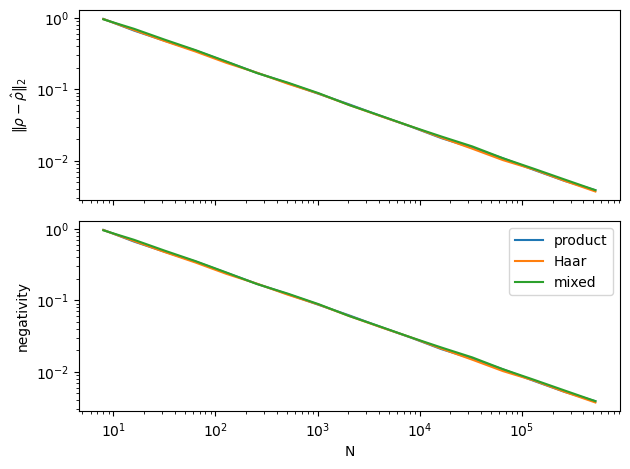

In [19]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True)

# Accuracy
for name, fs in zip(names, mean_fss):
    ax1.plot(Ns, fs, label=name)

# plt.xlabel('N')
ax1.set_ylabel(r'$\| \rho - \hat\rho \|_2$')
# plt.legend(loc='best')

ax1.set_xscale('log')
ax1.set_yscale('log')

# Negativity
for name, fs in zip(names, mean_fss):
    ax2.plot(Ns, fs, label=name)

ax2.set_xlabel('N')
ax2.set_ylabel('negativity')

ax2.set_xscale('log')
ax2.set_yscale('log')

plt.legend(loc='best')
plt.tight_layout()

plt.savefig('../plots/accuracy_negativity.pdf')

plt.show()
plt.close()